In [0]:
import pandas as pd
df_read=pd.read_csv("netflix_feature.csv")
print(df_read.shape)
df_read.head()

(8807, 18)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,origin_label,primary_genre,content_length_category,content_age_years,title_length_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 Min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Licensed,Documentaries,Medium,5,Medium
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,Licensed,International TV Shows,Multi Season,4,Medium
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Licensed,Crime TV Shows,Single Season,4,Short
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Licensed,Docuseries,Single Season,4,Long
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,Licensed,International TV Shows,Multi Season,4,Medium


In [0]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans

# Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['listed_in'].str.split(', ')
genre_features = mlb.fit_transform(genres)

# Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximate: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(extract_duration, axis=1).values.reshape(-1, 1)

# Prepare rating feature (label encoding)
rating_map = {k: v for v, k in enumerate(df_read['rating'].unique())}
rating_feature = df_read['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# Combine features
import numpy as np
X = np.hstack([genre_features, duration_feature, rating_feature])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

display(df_read[['title', 'listed_in', 'duration', 'rating', 'cluster']])

title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 Min,PG-13,2
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,TV-MA,2
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,4
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,TV-MA,2
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,TV-MA,2
My Little Pony: A New Generation,Children & Family Movies,91 Min,PG,2
Sankofa,"Dramas, Independent Movies, International Movies",125 Min,TV-MA,1
The Great British Baking Show,"British TV Shows, Reality TV",9 Seasons,TV-14,4
The Starling,"Comedies, Dramas",104 Min,PG-13,2


In [0]:
# Classification using Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Copy dataset
df_features = df_read.copy()

# --- Feature preparation ---
# Select relevant features
feature_cols = ['duration', 'content_age_years', 'primary_genre', 'rating']

# Encode categorical features
df_features['primary_genre'] = df_features['primary_genre'].astype('category').cat.codes
df_features['rating'] = df_features['rating'].astype('category').cat.codes

# Extract numeric part of duration (e.g., "90 min" → 90)
df_features['duration'] = (
    df_features['duration']
    .str.extract(r'(\d+)')
    .astype(float)
    .fillna(0)
)

# Fill missing numeric values
df_features['content_age_years'] = df_features['content_age_years'].fillna(0)

# --- Features and target ---
X = df_features[feature_cols]
y = df_features['type'].map({'Movie': 0, 'TV Show': 1})

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train classifier ---
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# --- Predict and evaluate ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))


              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1214
     TV Show       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



In [0]:
%pip install --upgrade matplotlib seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/home/spark-dcafcc03-a3e7-4b2d-9e21-86/.ipykernel/4385/command-6059008208354131-3254250612:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df_read, palette='coolwarm', edgecolor='black')


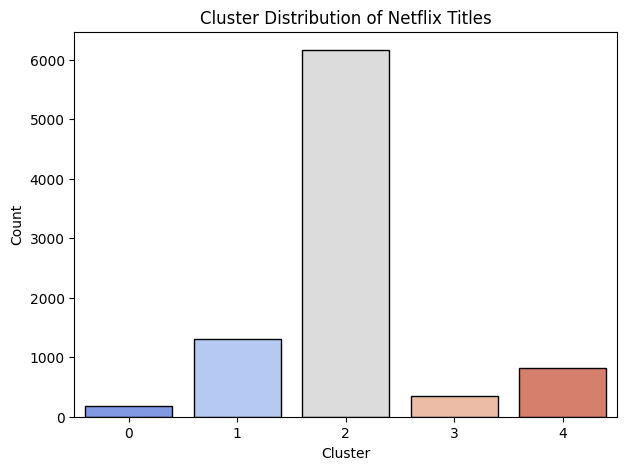

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(x='cluster', data=df_read, palette='coolwarm', edgecolor='black')
plt.title('Cluster Distribution of Netflix Titles')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [0]:
import seaborn as sns
# Get feature importances from the trained classifier
importances = clf.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# Display table
display(feat_imp_df)

sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5561717089819205>, line 3
      1 import seaborn as sns
      2 # Get feature importances from the trained classifier
----> 3 importances = clf.feature_importances_
      4 feature_names = X.columns
      6 # Create a DataFrame for better visualization

NameError: name 'clf' is not defined

Analysis of key drivers for content availability across countries and genres.

In [0]:

# --- 1️ Data Preparation ---
df_exploded = df_read.copy()
df_exploded['country'] = df_exploded['country'].fillna('Unknown')
df_exploded['listed_in'] = df_exploded['listed_in'].fillna('Unknown')

# Split multiple countries and genres into separate rows
df_exploded = df_exploded.assign(
    country=df_exploded['country'].str.split(', '),
    genre=df_exploded['listed_in'].str.split(', ')
).explode('country').explode('genre')
df_exploded
# --- 2️ Aggregate: count content per country and genre ---
country_genre_counts = (
    df_exploded.groupby(['country', 'genre'])
    .size()
    .reset_index(name='content_count')
)

display(country_genre_counts.sort_values('content_count', ascending=False).head(20))




country,genre,content_count
India,International Movies,864
United States,Dramas,835
United States,Comedies,680
India,Dramas,662
United States,Documentaries,511
United States,Action & Adventure,404
United States,Children & Family Movies,390
United States,Independent Movies,390
India,Comedies,323
United States,Thrillers,292


In [0]:

# --- 3️ Feature Engineering: top countries & genres ---
top_countries = df_exploded['country'].value_counts().head(10).index.tolist()
top_genres = df_exploded['genre'].value_counts().head(10).index.tolist()

df_exploded['is_top_country'] = df_exploded['country'].isin(top_countries).astype(int)
df_exploded['is_top_genre'] = df_exploded['genre'].isin(top_genres).astype(int)
df_exploded['rating'] = df_exploded['rating'].astype('category').cat.codes
df_exploded['duration'] = (
    df_exploded['duration'].astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
    .fillna(0)
)
df_exploded['release_year'] = pd.to_numeric(df_exploded['release_year'], errors='coerce').fillna(0)
df_exploded['content_age_years'] = 2025 - df_exploded['release_year']

# --- 4️ Logistic Regression to Identify Key Drivers ---
feature_cols = ['duration', 'rating', 'content_age_years', 'is_top_genre']
X = df_exploded[feature_cols]
y = df_exploded['is_top_country']
display(X,y)
clf = LogisticRegression(max_iter=200)
clf.fit(X, y)

# --- 5️ Feature Importance (Coefficients) ---
driver_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': clf.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

display(driver_df)



duration,rating,content_age_years,is_top_genre
90.0,8,5,1
2.0,12,4,1
2.0,12,4,1
2.0,12,4,0
1.0,12,4,0
1.0,12,4,1
1.0,12,4,0
1.0,12,4,0
1.0,12,4,0
2.0,12,4,1


Feature,Coefficient
is_top_genre,-0.60667635841186
rating,-0.07144867110627355
content_age_years,0.006573489232566837
duration,3.822074563697002E-4


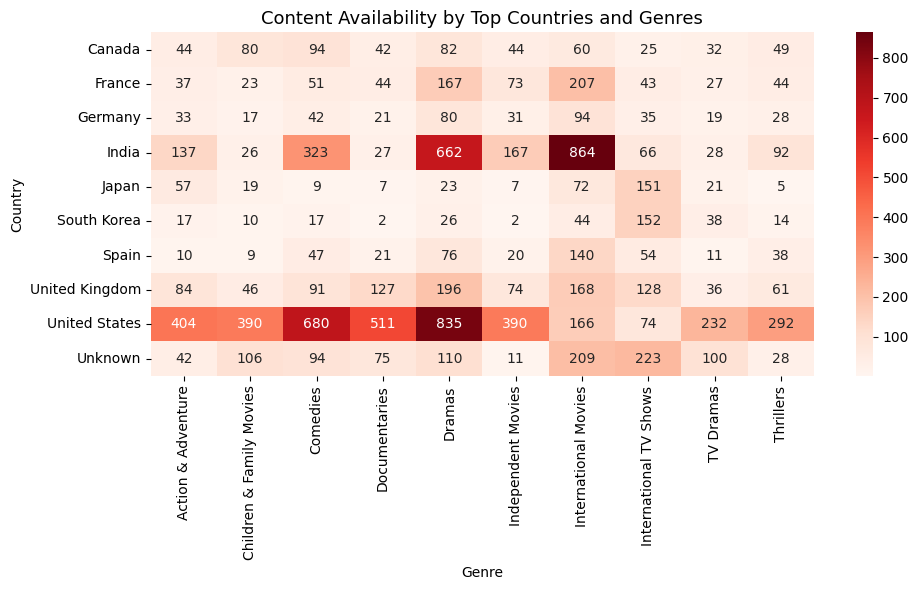

In [0]:
# --- 6️ Visualization: Heatmap of Content Availability ---
pivot = country_genre_counts[
    country_genre_counts['country'].isin(top_countries) &
    country_genre_counts['genre'].isin(top_genres)
].pivot(index='country', columns='genre', values='content_count').fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds')  # Examples: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'YlOrRd', 'BuPu', 'RdPu', 'PuRd', 'YlGnBu', 'YlGn', 'cubehelix', 'Spectral'
plt.title('Content Availability by Top Countries and Genres', fontsize=13)
plt.xlabel('Genre')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


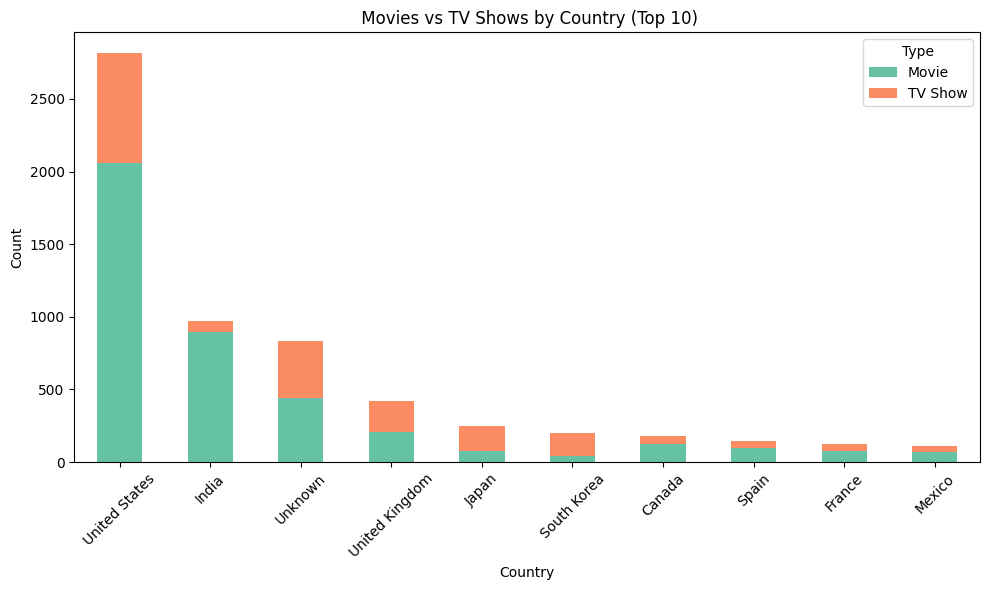

In [0]:
#  Counting Movies vs TV Shows by country
# ===============================================================
country_type = df_read.groupby(['country', 'type']).size().unstack(fill_value=0)
top_countries = country_type.sum(axis=1).sort_values(ascending=False).head(10)

# Filter top 10 countries only
country_type_top = country_type.loc[top_countries.index]

# Plot
country_type_top.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])
plt.title(' Movies vs TV Shows by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


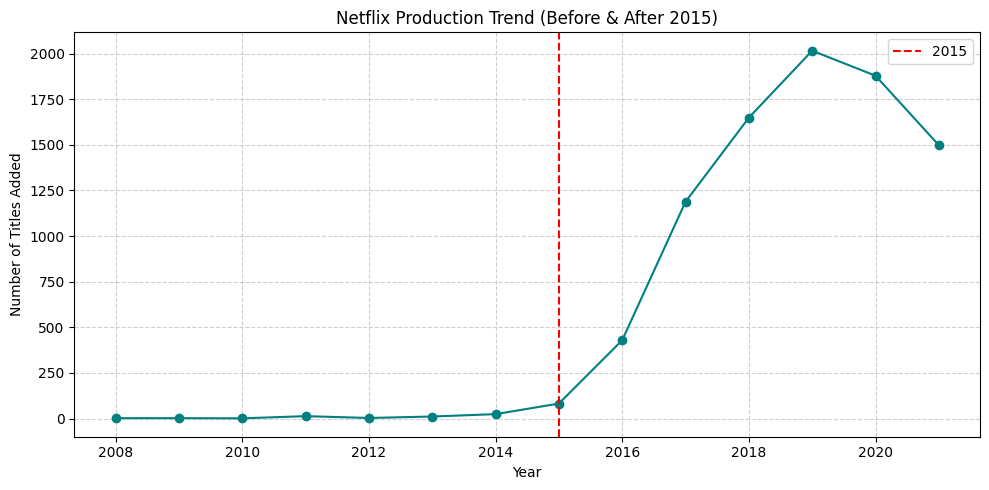

In [0]:
# Ensure 'date_added' is datetime
df_read['date_added'] = pd.to_datetime(
    df_read['date_added'],
    errors='coerce'
)
df_read['year_added'] = df_read['date_added'].dt.year

trend = df_read.groupby('year_added').size()

plt.figure(figsize=(10, 5))
plt.plot(trend.index, trend.values, marker='o', color='teal')
plt.axvline(x=2015, color='red', linestyle='--', label='2015')
plt.title('Netflix Production Trend (Before & After 2015)')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

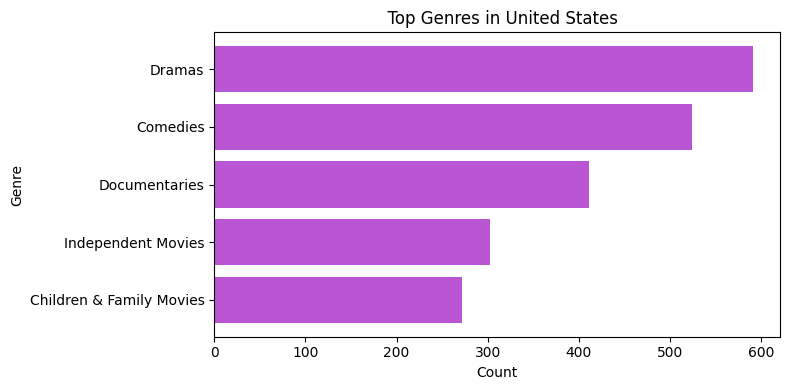

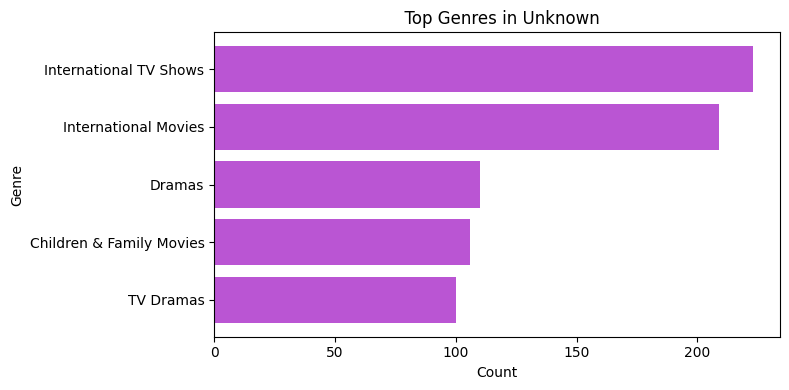

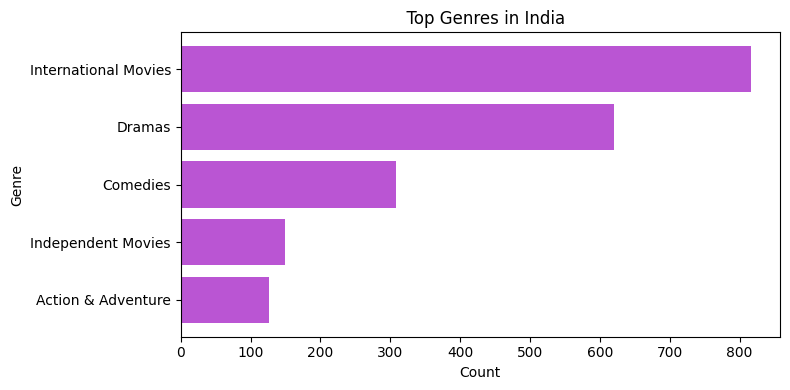

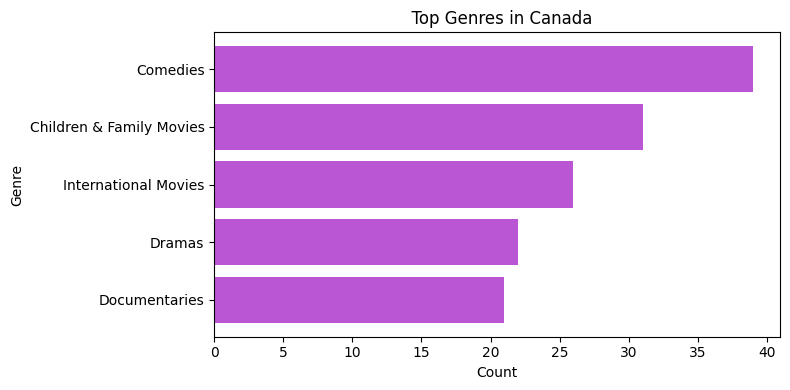

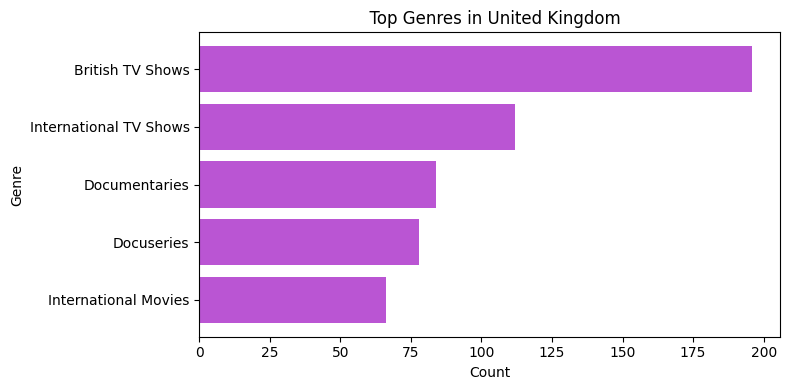

In [0]:
# 🎭 3. Finding the Top Genres per Country
# ===============================================================
# Split genres
df_read['genre_list'] = df_read['listed_in'].apply(lambda x: [g.strip() for g in str(x).split(',')])

# Explode to rows
genre_country = df_read.explode('genre_list')

# Count top genres per country
top_genres = genre_country.groupby(['country', 'genre_list']).size().reset_index(name='count')

# Get top 5 genres for each country
top_genres_per_country = top_genres.sort_values(['country', 'count'], ascending=[True, False]).groupby('country').head(5)

# Plot for top 5 countries
top_countries = top_genres['country'].value_counts().head(5).index
for country in top_countries:
    data = top_genres_per_country[top_genres_per_country['country'] == country]
    plt.figure(figsize=(8, 4))
    plt.barh(data['genre_list'], data['count'], color='mediumorchid')
    plt.title(f'  Top Genres in {country}')
    plt.xlabel('Count')
    plt.ylabel('Genre')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()